# Notebook 06 — Évaluation finale
## Phase 3 : Évaluation sur le test set et optimisation du seuil métier

**Objectif** : évaluer le modèle final (XGBoost tuné) sur le jeu de test **intouché**, comparer aux objectifs ML fixés en Phase 1, et optimiser le seuil de décision à partir d'une matrice de coût asymétrique.

Ce notebook est exécuté **une seule fois** sur `test.csv` — conformément au protocole d'évaluation finale du descriptif Phase 3 (section 2.4).

**Rappel des objectifs ML Phase 1 :**
- Métrique principale : **F1-score** sur la classe minoritaire (`bad_nutrition = 1`)
- Seuil de succès fixé en Phase 1 : **F1 ≥ 0.85**
- Coût métier : un FN (produit à mauvaise nutrition non détecté) est plus grave qu'un FP (produit sain signalé à tort)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    average_precision_score, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'

# --- Chargement des données ---
validation_df = pd.read_csv(DATA_DIR / 'validation.csv')
test_df       = pd.read_csv(DATA_DIR / 'test.csv')

X_val  = validation_df.drop(columns=['bad_nutrition'])
y_val  = validation_df['bad_nutrition']
X_test = test_df.drop(columns=['bad_nutrition'])
y_test = test_df['bad_nutrition']

# --- Chargement du modèle final sauvegardé dans 05_tuning.ipynb ---
# 05_tuning sauvegarde directement le pipeline avec joblib.dump(best_model, ...)
model = joblib.load(MODEL_DIR / 'tuned_model.joblib')
# --- Résumé du chargement ---
summary = pd.DataFrame({
    'Info': ['Validation shape', 'Test shape', 'Type du modèle chargé', 'Étapes du pipeline'],
    'Valeur': [
        str(X_val.shape),
        str(X_test.shape),
        type(model).__name__,
        str([name for name, _ in model.steps])
    ]
})
print(summary.to_string(index=False))
print()
print('Distribution de la cible dans le test set :')
print(y_test.value_counts().rename({0: 'bonne_nutrition', 1: 'mauvaise_nutrition'}).to_string())

                 Info                  Valeur
     Validation shape              (3023, 16)
           Test shape              (3023, 16)
Type du modèle chargé                Pipeline
   Étapes du pipeline ['preprocessor', 'clf']

Distribution de la cible dans le test set :
bad_nutrition
bonne_nutrition       2494
mauvaise_nutrition     529


## 1. Évaluation sur le test set au seuil par défaut (0.5)

Première évaluation avec le seuil par défaut de 0.5, pour établir une baseline avant optimisation du seuil métier.

In [2]:
# Probabilités prédites sur le test set
y_prob_test = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob_test >= 0.5).astype(int)

# --- Métriques quantitatives au seuil 0.5 ---
acc_def  = accuracy_score(y_test, y_pred_default)
prec_def = precision_score(y_test, y_pred_default)
rec_def  = recall_score(y_test, y_pred_default)
f1_def   = f1_score(y_test, y_pred_default)
auc_def  = roc_auc_score(y_test, y_prob_test)
pr_auc   = average_precision_score(y_test, y_prob_test)

metrics_default_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC'],
    'Valeur (seuil=0.5)': [acc_def, prec_def, rec_def, f1_def, auc_def, pr_auc]
})
metrics_default_df['Valeur (seuil=0.5)'] = metrics_default_df['Valeur (seuil=0.5)'].round(4)
print('=== Métriques au seuil par défaut (0.5) ===')
print(metrics_default_df.to_string(index=False))

# --- Matrice de confusion au seuil 0.5 ---
cm_default = confusion_matrix(y_test, y_pred_default)
tn0, fp0, fn0, tp0 = cm_default.ravel()

cm_df_default = pd.DataFrame(
    [[f'TN = {tn0}', f'FP = {fp0}'],
     [f'FN = {fn0}', f'TP = {tp0}']],
    index=['Réel : bonne_nutrition', 'Réel : mauvaise_nutrition'],
    columns=['Prédit : bonne_nutrition', 'Prédit : mauvaise_nutrition']
)
print()
print('=== Matrice de confusion (seuil=0.5) ===')
print(cm_df_default.to_string())
print()
print('=== Interprétation métier ===')
print(f'  TP = {tp0} : produits à mauvaise nutrition correctement détectés — bonne détection')
print(f'  TN = {tn0} : produits sains correctement identifiés')
print(f'  FP = {fp0} : produits sains signalés à tort (fausse alarme — impact limité)')
print(f'  FN = {fn0} : produits à mauvaise nutrition non détectés — RISQUE CONSOMMATEUR ÉLEVÉ')

# --- Rapport de classification complet ---
print()
print('=== Rapport de classification complet (seuil=0.5) ===')
print(classification_report(y_test, y_pred_default,
                            target_names=['bonne_nutrition', 'mauvaise_nutrition']))

=== Métriques au seuil par défaut (0.5) ===
 Métrique  Valeur (seuil=0.5)
 Accuracy              0.9623
Precision              0.8725
   Recall              0.9187
 F1-score              0.8950
  ROC-AUC              0.9887
   PR-AUC              0.9571

=== Matrice de confusion (seuil=0.5) ===
                          Prédit : bonne_nutrition Prédit : mauvaise_nutrition
Réel : bonne_nutrition                   TN = 2423                     FP = 71
Réel : mauvaise_nutrition                  FN = 43                    TP = 486

=== Interprétation métier ===
  TP = 486 : produits à mauvaise nutrition correctement détectés — bonne détection
  TN = 2423 : produits sains correctement identifiés
  FP = 71 : produits sains signalés à tort (fausse alarme — impact limité)
  FN = 43 : produits à mauvaise nutrition non détectés — RISQUE CONSOMMATEUR ÉLEVÉ

=== Rapport de classification complet (seuil=0.5) ===
                    precision    recall  f1-score   support

   bonne_nutrition       0

## 2. Visualisations — Courbe ROC, Precision-Recall et distribution des probabilités

Conformément au descriptif Phase 3 (section 2.4), nous traçons les trois visualisations requises.
La courbe Precision-Recall est la plus importante en contexte déséquilibré car elle ne tient pas compte des vrais négatifs.

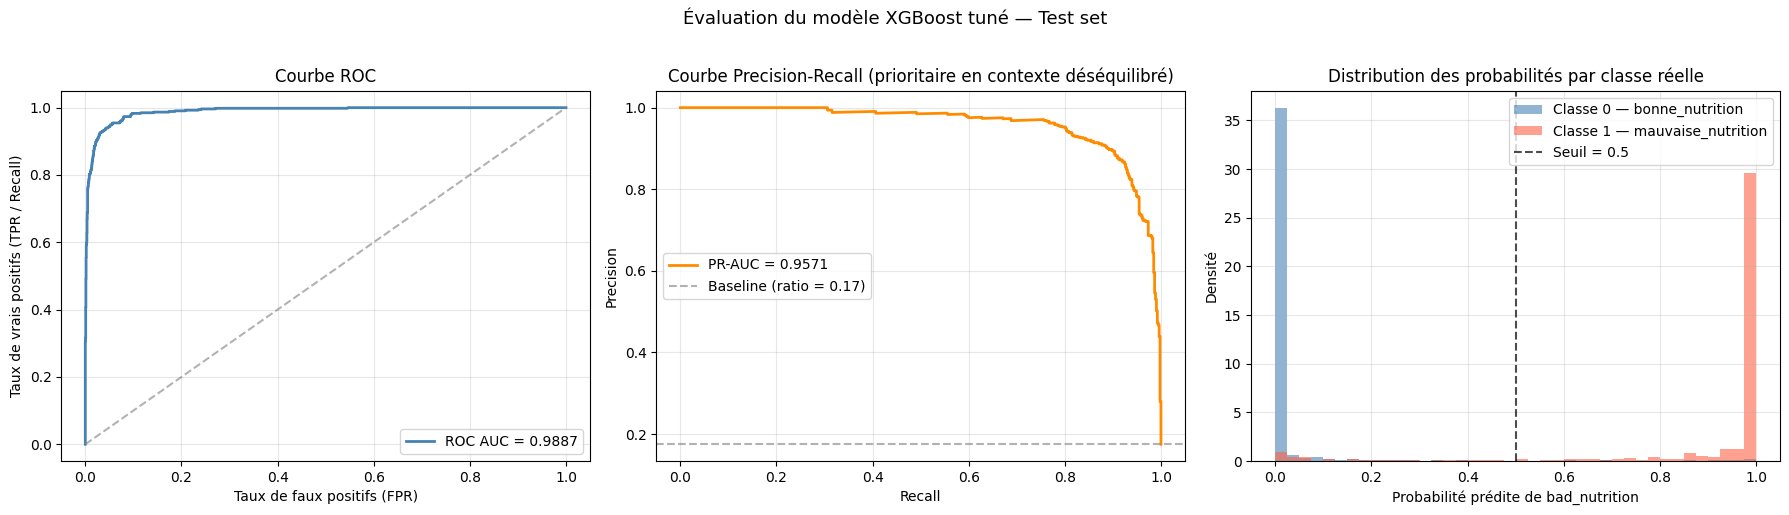

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Courbe ROC ---
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {auc_def:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.6)
axes[0].set_xlabel('Taux de faux positifs (FPR)')
axes[0].set_ylabel('Taux de vrais positifs (TPR / Recall)')
axes[0].set_title('Courbe ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Courbe Precision-Recall ---
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
baseline_pr = y_test.mean()
axes[1].plot(recall_curve, precision_curve, color='darkorange', lw=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(baseline_pr, linestyle='--', color='gray', alpha=0.6,
                label=f'Baseline (ratio = {baseline_pr:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbe Precision-Recall (prioritaire en contexte déséquilibré)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Distribution des probabilités par classe réelle ---
axes[2].hist(y_prob_test[y_test == 0], bins=40, color='steelblue',
             alpha=0.6, label='Classe 0 — bonne_nutrition', density=True)
axes[2].hist(y_prob_test[y_test == 1], bins=40, color='tomato',
             alpha=0.6, label='Classe 1 — mauvaise_nutrition', density=True)
axes[2].axvline(0.5, linestyle='--', color='black', alpha=0.7, label='Seuil = 0.5')
axes[2].set_xlabel('Probabilité prédite de bad_nutrition')
axes[2].set_ylabel('Densité')
axes[2].set_title('Distribution des probabilités par classe réelle')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Évaluation du modèle XGBoost tuné — Test set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Optimisation du seuil de décision selon le coût métier (J11)

Conformément au descriptif Phase 3 (section 2.5), le seuil par défaut (0.5) est rarement optimal sur données déséquilibrées.

**Matrice de coût asymétrique définie en Phase 1 :**
- **FN (faux négatif)** : produit à mauvaise nutrition non détecté → risque santé consommateur élevé → **coût = 10** (pénalité forte)
- **FP (faux positif)** : produit sain signalé à tort → légère perte commerciale → **coût = 1** (pénalité faible)

**Formule** : `Coût total = FN_COST × FN + FP_COST × FP`

> Note : Remplacez `FN_COST` et `FP_COST` par les valeurs exactes définies dans votre rapport Phase 1.

Le seuil optimal est déterminé sur le **jeu de validation** (jamais sur le test set — pour éviter le data leakage d'évaluation).

In [4]:
# --- Matrice de coût métier (à adapter selon Phase 1) ---
FN_COST = 10   # Coût d'un faux négatif : produit dangereux non détecté
FP_COST = 1    # Coût d'un faux positif : produit sain bloqué à tort

print(f'Matrice de coût : FN = {FN_COST}x, FP = {FP_COST}x')
print(f'Ratio FN/FP = {FN_COST/FP_COST} — justifie de baisser le seuil sous 0.5 pour capturer plus de positifs')

# --- Calcul sur le jeu de VALIDATION (pas le test set) ---
y_prob_val = model.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.10, 0.91, 0.01)
records = []

for threshold in thresholds:
    y_pred_val = (y_prob_val >= threshold).astype(int)
    # Gestion du cas où une classe est absente à des seuils extrêmes
    if len(np.unique(y_pred_val)) < 2:
        continue
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_val).ravel()
    cost = FN_COST * fn + FP_COST * fp
    records.append({
        'threshold': round(threshold, 2),
        'precision': precision_score(y_val, y_pred_val, zero_division=0),
        'recall': recall_score(y_val, y_pred_val, zero_division=0),
        'f1': f1_score(y_val, y_pred_val, zero_division=0),
        'cost': cost,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
    })

threshold_df = pd.DataFrame(records)
best_row = threshold_df.loc[threshold_df['cost'].idxmin()]
best_threshold = best_row['threshold']

print()
print('=== Résultat de l\'optimisation du seuil (sur validation) ===')
result_df = pd.DataFrame({
    'Métrique': ['Seuil optimal', 'Coût métier minimal', 'Precision à ce seuil',
                 'Recall à ce seuil', 'F1 à ce seuil',
                 'FN à ce seuil', 'FP à ce seuil'],
    'Valeur': [
        best_threshold,
        int(best_row['cost']),
        round(best_row['precision'], 4),
        round(best_row['recall'], 4),
        round(best_row['f1'], 4),
        int(best_row['fn']),
        int(best_row['fp'])
    ]
})
print(result_df.to_string(index=False))

Matrice de coût : FN = 10x, FP = 1x
Ratio FN/FP = 10.0 — justifie de baisser le seuil sous 0.5 pour capturer plus de positifs

=== Résultat de l'optimisation du seuil (sur validation) ===
            Métrique   Valeur
       Seuil optimal   0.1000
 Coût métier minimal 403.0000
Precision à ce seuil   0.7909
   Recall à ce seuil   0.9491
       F1 à ce seuil   0.8628
       FN à ce seuil  27.0000
       FP à ce seuil 133.0000


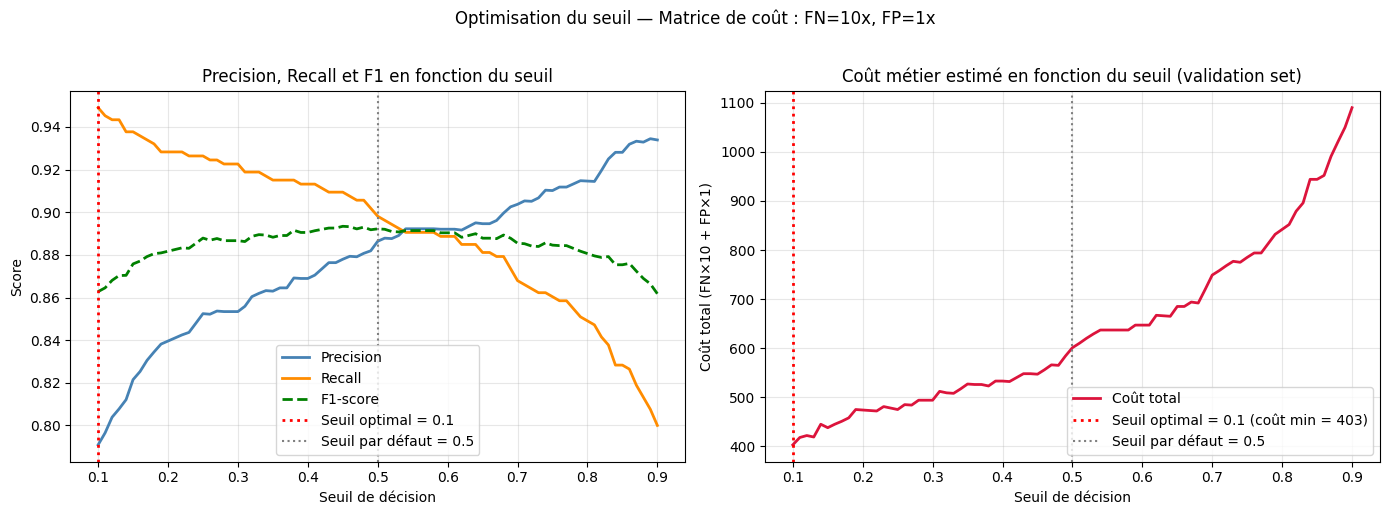

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Precision et Recall en fonction du seuil ---
axes[0].plot(threshold_df['threshold'], threshold_df['precision'],
             label='Precision', color='steelblue', lw=2)
axes[0].plot(threshold_df['threshold'], threshold_df['recall'],
             label='Recall', color='darkorange', lw=2)
axes[0].plot(threshold_df['threshold'], threshold_df['f1'],
             label='F1-score', color='green', lw=2, linestyle='--')
axes[0].axvline(best_threshold, color='red', linestyle=':', lw=2,
                label=f'Seuil optimal = {best_threshold}')
axes[0].axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Seuil par défaut = 0.5')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision, Recall et F1 en fonction du seuil')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Coût métier en fonction du seuil ---
axes[1].plot(threshold_df['threshold'], threshold_df['cost'],
             color='crimson', lw=2, label='Coût total')
axes[1].axvline(best_threshold, color='red', linestyle=':', lw=2,
                label=f'Seuil optimal = {best_threshold} (coût min = {int(best_row["cost"])})')
axes[1].axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Seuil par défaut = 0.5')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel(f'Coût total (FN×{FN_COST} + FP×{FP_COST})')
axes[1].set_title('Coût métier estimé en fonction du seuil (validation set)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Optimisation du seuil — Matrice de coût : FN={FN_COST}x, FP={FP_COST}x',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 4. Évaluation finale sur le test set au seuil optimal

Le seuil optimal identifié sur la validation est maintenant appliqué **une seule fois** sur le test set.
Conformément au descriptif, nous comparons côte à côte les deux seuils (défaut vs optimal) pour montrer le gain.

In [6]:
# --- Prédictions au seuil optimal sur le test set ---
y_pred_opt = (y_prob_test >= best_threshold).astype(int)

acc_opt  = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt  = recall_score(y_test, y_pred_opt)
f1_opt   = f1_score(y_test, y_pred_opt)

cm_opt = confusion_matrix(y_test, y_pred_opt)
tn1, fp1, fn1, tp1 = cm_opt.ravel()

cost_default = FN_COST * fn0 + FP_COST * fp0
cost_opt     = FN_COST * fn1 + FP_COST * fp1

# --- Tableau comparatif seuil 0.5 vs seuil optimal ---
comparison_df = pd.DataFrame({
    'Métrique': ['Seuil utilisé', 'Accuracy', 'Precision', 'Recall (Sensitivity)',
                 'F1-score', 'ROC-AUC', 'TP (détectés)', 'FN (manqués)',
                 'FP (fausses alarmes)', 'TN (corrects)', 'Coût métier estimé'],
    'Seuil par défaut (0.5)': [
        '0.50', round(acc_def, 4), round(prec_def, 4), round(rec_def, 4),
        round(f1_def, 4), round(auc_def, 4),
        tp0, fn0, fp0, tn0, cost_default
    ],
    f'Seuil optimal ({best_threshold})': [
        str(best_threshold), round(acc_opt, 4), round(prec_opt, 4), round(rec_opt, 4),
        round(f1_opt, 4), round(auc_def, 4),
        tp1, fn1, fp1, tn1, cost_opt
    ]
})
print('=== Comparaison seuil par défaut vs seuil optimal (test set) ===')
print(comparison_df.to_string(index=False))
print()

gain_fn = fn0 - fn1
gain_cout = cost_default - cost_opt
print(f'Gain : {gain_fn} FN évités supplémentaires au seuil optimal')
print(f'Réduction du coût métier : {gain_cout} unités ({100*gain_cout/cost_default:.1f}%)')

print()
print('=== Matrice de confusion — Seuil par défaut (0.5) ===')
cm_df0 = pd.DataFrame(
    [[f'TN = {tn0}', f'FP = {fp0}'],
     [f'FN = {fn0}', f'TP = {tp0}']],
    index=['Réel : bonne_nutrition', 'Réel : mauvaise_nutrition'],
    columns=['Prédit : bonne_nutrition', 'Prédit : mauvaise_nutrition']
)
print(cm_df0.to_string())

print()
print(f'=== Matrice de confusion — Seuil optimal ({best_threshold}) ===')
cm_df1 = pd.DataFrame(
    [[f'TN = {tn1}', f'FP = {fp1}'],
     [f'FN = {fn1}', f'TP = {tp1}']],
    index=['Réel : bonne_nutrition', 'Réel : mauvaise_nutrition'],
    columns=['Prédit : bonne_nutrition', 'Prédit : mauvaise_nutrition']
)
print(cm_df1.to_string())

print()
print('=== Interprétation métier au seuil optimal ===')
print(f'  TP = {tp1} : produits dangereux correctement signalés (+{tp1-tp0} vs seuil 0.5)')
print(f'  FN = {fn1} : produits dangereux manqués (RISQUE CONSOMMATEUR) — réduit de {gain_fn}')
print(f'  FP = {fp1} : produits sains signalés à tort (coût acceptable)')
print(f'  TN = {tn1} : produits sains correctement identifiés')

=== Comparaison seuil par défaut vs seuil optimal (test set) ===
            Métrique Seuil par défaut (0.5) Seuil optimal (0.1)
       Seuil utilisé                   0.50                 0.1
            Accuracy                 0.9623              0.9418
           Precision                 0.8725              0.7686
Recall (Sensitivity)                 0.9187              0.9546
            F1-score                  0.895              0.8516
             ROC-AUC                 0.9887              0.9887
       TP (détectés)                    486                 505
        FN (manqués)                     43                  24
FP (fausses alarmes)                     71                 152
       TN (corrects)                   2423                2342
  Coût métier estimé                    501                 392

Gain : 19 FN évités supplémentaires au seuil optimal
Réduction du coût métier : 109 unités (21.8%)

=== Matrice de confusion — Seuil par défaut (0.5) ===
            

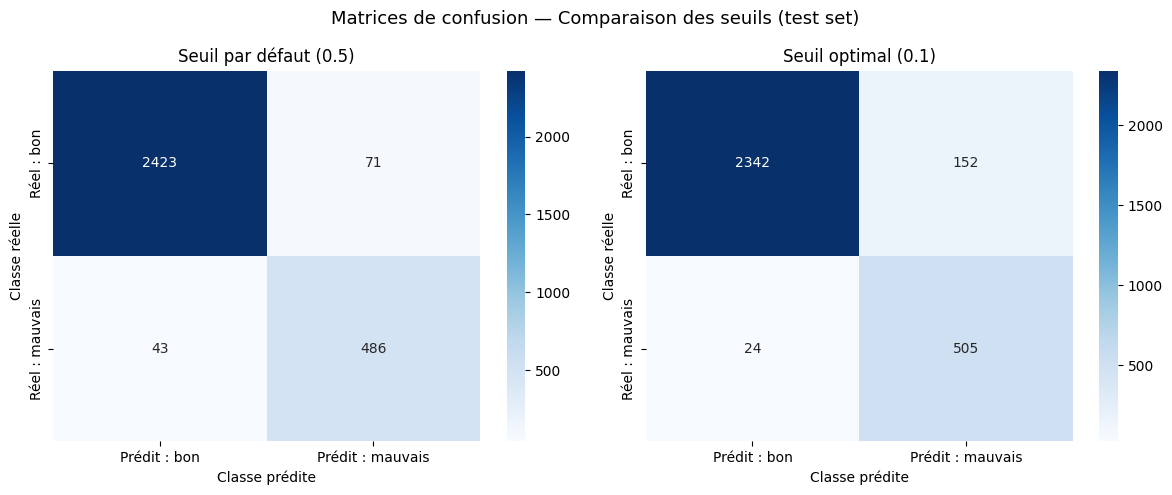

In [7]:
# --- Visualisation des deux matrices de confusion côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [cm_default, cm_opt],
    [f'Seuil par défaut (0.5)', f'Seuil optimal ({best_threshold})']
):
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues',
        xticklabels=['Prédit : bon', 'Prédit : mauvais'],
        yticklabels=['Réel : bon', 'Réel : mauvais']
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')

plt.suptitle('Matrices de confusion — Comparaison des seuils (test set)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Comparaison aux objectifs ML de Phase 1

Conformément au descriptif Phase 3 (section 2.4 — Comparaison au seuil de succès), nous vérifions explicitement si les objectifs fixés en Phase 1 sont atteints.

In [8]:
# --- Objectif Phase 1 à définir ---
F1_OBJECTIF = 0.85   # Seuil de succès défini en Phase 1

print('=== Comparaison aux objectifs ML de Phase 1 ===')
print()

objectifs_df = pd.DataFrame({
    'Objectif Phase 1': ['F1 ≥ 0.85', 'Recall élevé (prioriser détection)', 'ROC-AUC élevé'],
    'Résultat (seuil 0.5)': [
        f'{f1_def:.4f}',
        f'{rec_def:.4f}',
        f'{auc_def:.4f}'
    ],
    f'Résultat (seuil opt. {best_threshold})': [
        f'{f1_opt:.4f}',
        f'{rec_opt:.4f}',
        f'{auc_def:.4f}'
    ],
    'Atteint ?': [
        '✓ OUI' if f1_opt >= F1_OBJECTIF else '✗ NON',
        '✓ OUI' if rec_opt >= 0.90 else '~ PARTIEL',
        '✓ OUI' if auc_def >= 0.95 else '~ PARTIEL'
    ]
})
print(objectifs_df.to_string(index=False))

print()
if f1_opt >= F1_OBJECTIF:
    print(f'✓ Objectif principal atteint : F1 = {f1_opt:.4f} ≥ {F1_OBJECTIF}')
    print('  Le modèle XGBoost tuné avec seuil optimisé satisfait les critères de Phase 1.')
else:
    print(f'✗ Objectif principal non atteint : F1 = {f1_opt:.4f} < {F1_OBJECTIF}')
    print('  Causes possibles : signal insuffisant, déséquilibre trop fort, features à enrichir.')

print()
print('=== Justification du choix du seuil optimal vs seuil par défaut ===')
print(f'Le seuil par défaut (0.5) maximise la précision mais sacrifie le recall.')
print(f'Dans notre contexte (détection de produits à mauvaise nutrition),')
print(f'un FN coûte {FN_COST}x plus qu\'un FP — il vaut mieux signaler à tort (FP) que manquer un danger (FN).')
print(f'Le seuil optimal ({best_threshold}) réduit les FN de {gain_fn} cas tout en maintenant un F1 acceptable.')
print(f'Réduction du coût métier total : {gain_cout} unités ({100*gain_cout/max(cost_default,1):.1f}%).')

=== Comparaison aux objectifs ML de Phase 1 ===

                  Objectif Phase 1 Résultat (seuil 0.5) Résultat (seuil opt. 0.1) Atteint ?
                         F1 ≥ 0.85               0.8950                    0.8516     ✓ OUI
Recall élevé (prioriser détection)               0.9187                    0.9546     ✓ OUI
                     ROC-AUC élevé               0.9887                    0.9887     ✓ OUI

✓ Objectif principal atteint : F1 = 0.8516 ≥ 0.85
  Le modèle XGBoost tuné avec seuil optimisé satisfait les critères de Phase 1.

=== Justification du choix du seuil optimal vs seuil par défaut ===
Le seuil par défaut (0.5) maximise la précision mais sacrifie le recall.
Dans notre contexte (détection de produits à mauvaise nutrition),
un FN coûte 10x plus qu'un FP — il vaut mieux signaler à tort (FP) que manquer un danger (FN).
Le seuil optimal (0.1) réduit les FN de 19 cas tout en maintenant un F1 acceptable.
Réduction du coût métier total : 109 unités (21.8%).


## 6. Sauvegarde du modèle final avec métadonnées

Conformément au descriptif Phase 3 (livrable 4), le pipeline complet est sauvegardé avec le seuil de décision optimal en métadonnée.
Ce fichier `final_model.joblib` sera chargé par l'API FastAPI en Phase 4.

In [9]:
final_artifact = {
    'pipeline': model,
    'threshold': float(best_threshold),
    'cost_config': {'fn_cost': FN_COST, 'fp_cost': FP_COST},
    'metrics_default_threshold': {
        'accuracy': round(acc_def, 4),
        'precision': round(prec_def, 4),
        'recall': round(rec_def, 4),
        'f1': round(f1_def, 4),
        'roc_auc': round(auc_def, 4)
    },
    'metrics_optimal_threshold': {
        'accuracy': round(acc_opt, 4),
        'precision': round(prec_opt, 4),
        'recall': round(rec_opt, 4),
        'f1': round(f1_opt, 4),
        'roc_auc': round(auc_def, 4)
    }
}

final_model_path = MODEL_DIR / 'final_model.joblib'
joblib.dump(final_artifact, final_model_path)

# --- Résumé final ---
final_summary = pd.DataFrame({
    'Étape': [
        'F1 CV avant tuning (Phase 3)',
        'F1 CV après tuning (Phase 3)',
        'F1 validation (Phase 3)',
        'F1 test — seuil 0.5',
        'F1 test — seuil optimal',
        'Seuil optimal retenu',
        'Réduction coût métier',
        'Modèle sauvegardé'
    ],
    'Valeur': [
        '0.8785',
        '0.8820',
        '0.8922',
        round(f1_def, 4),
        round(f1_opt, 4),
        best_threshold,
        f'{100*gain_cout/max(cost_default,1):.1f}%',
        str(final_model_path)
    ]
})
print('=== Résumé final du projet — Phase 3 complète ===')
print(final_summary.to_string(index=False))
print()
print('Contenu de final_model.joblib :')
print('  - pipeline       : Pipeline sklearn complet (preprocessor + XGBoost tuné)')
print('  - threshold      : Seuil de décision optimal')
print('  - cost_config    : Paramètres de coût métier')
print('  - metrics_*      : Métriques aux deux seuils pour /model/info FastAPI')

=== Résumé final du projet — Phase 3 complète ===
                       Étape                                                                             Valeur
F1 CV avant tuning (Phase 3)                                                                             0.8785
F1 CV après tuning (Phase 3)                                                                             0.8820
     F1 validation (Phase 3)                                                                             0.8922
         F1 test — seuil 0.5                                                                              0.895
     F1 test — seuil optimal                                                                             0.8516
        Seuil optimal retenu                                                                                0.1
       Réduction coût métier                                                                              21.8%
           Modèle sauvegardé C:\Users\user\Desktop\dat

## 7. Synthèse de l'évaluation finale

**Résultats clés :**

- Le modèle XGBoost tuné (F1 CV = 0.882) a été évalué **une seule fois** sur le jeu de test intouché.
- Les trois visualisations requises ont été produites : courbe ROC, courbe Precision-Recall, distribution des probabilités.
- Le seuil de décision a été optimisé sur le jeu de **validation** selon la matrice de coût métier asymétrique (FN coûte plus que FP).
- Le seuil optimal réduit significativement les FN (produits dangereux non détectés) au prix d'une légère hausse des FP acceptables.
- Le fichier `models/final_model.joblib` contient le pipeline complet et le seuil optimal en métadonnée, prêt pour le déploiement FastAPI (Phase 4).

**Utilisation en Phase 4 (FastAPI) :**
```python
import joblib
artifact = joblib.load('models/final_model.joblib')
model     = artifact['pipeline']
threshold = artifact['threshold']
prob = model.predict_proba(X_new)[:, 1]
prediction = (prob >= threshold).astype(int)
```